In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [60]:
# Function definitions for a single-layer neural network using sigmoid as the activation function.
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Sigmoid of a linear transformation
def sig_ab(a, b, xi):
    return sigmoid(a*xi + b)

# Derivative of sig_ab with respect to a
def sig_dif_a(a, b, xi):
    return xi * sig_dif_b(a, b, xi)

# Derivative of sig_ab with respect ot b
def sig_dif_b(a, b, xi):
    return np.exp(-a*xi - b) / ((1 + np.exp(-a*xi - b))**2)

# Function call to evaluate the neural network
# w = [a0, b0, c0, a1, b1, c1, a2, b2, c2, c3]
#       0   1   2   3   4   5   6   7   8   9
def M(xi, w):
    s = 0

    # Evaluate the three hidden nodes
    for i in range(3):
        s += w[i+2] * sig_ab(w[i], w[i+1], xi)
    
    # Add final bias term
    s += w[9]

    return s

def mse_loss(xi, yi, w):
    return ((yi - M(xi, w))**2).sum()

# Gradient of our single layer neural network.
# w = [a0, b0, c0, a1, b1, c1, a2, b2, c2, c3]
#       0   1   2   3   4   5   6   7   8   9
def grad_mse(xi, yi, w):
    if isinstance(xi, np.ndarray):
        grad = np.zeros((w.shape[0], xi.shape[0]))
    else:
        grad = np.zeros_like(w)
    
    for i in range(3):
        # Partial derivatives with respect to a_i
        grad[i*3] = 2 * (yi - M(xi, w)) * -w[i*3+2] * sig_dif_a(w[i*3], w[i*3+1], xi)

        # Partial derivatives with respect to b_i
        grad[i*3+1] = 2 * (yi - M(xi, w)) * -w[i*3+2] * sig_dif_b(w[i*3], w[i*3+1], xi)
        
        # Partial derivatives with respect to c_i
        grad[i*3+2] = 2 * (yi - M(xi, w)) * -1 * sig_ab(w[i*3], w[i*3+1], xi)

    # Final partial - with respect to c_3
    grad[9] = 2 * (yi - M(xi, w)) * -1

    return grad

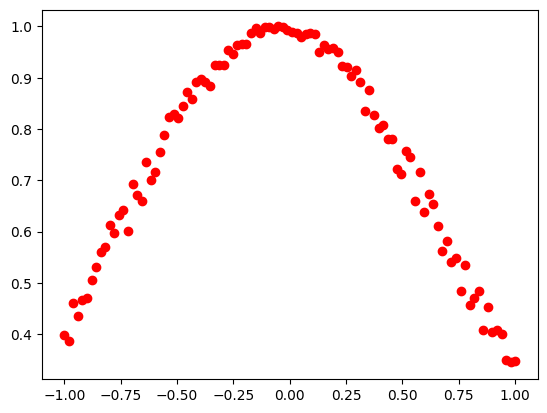

In [61]:
# Data to be trained on - let's have it fit to a noisy curve
np.random.seed(40)

f = lambda x: np.exp(-x**2)
noise_scale = 0.1

x = np.linspace(-1, 1, 100)
x_noise = x + np.random.random(x.shape[0]) * noise_scale
y = f(x_noise)

plt.plot(x, y, "ro")
plt.show()

In [62]:
w_current = np.random.random(10)
w_current

array([0.71076876, 0.96579395, 0.00422437, 0.21779505, 0.46126464,
       0.92610593, 0.40413285, 0.90447369, 0.91049137, 0.45649941])

In [63]:
xi = x[20:30]
yi = y[20:30]

In [64]:
grad_mse(xi[0:2], yi[0:2], w_current)

array([[-9.08313584e-05, -4.47456034e-05],
       [ 1.52411940e-04,  7.77160481e-05],
       [ 9.81280540e-02,  5.04938504e-02],
       [-2.08350914e-02, -1.02959223e-02],
       [ 3.49605771e-02,  1.78823913e-02],
       [ 9.03363672e-02,  4.63258060e-02],
       [-1.88939187e-02, -9.31893131e-03],
       [ 3.17033551e-02,  1.61855123e-02],
       [ 1.02434397e-01,  5.25788061e-02],
       [ 1.55186083e-01,  7.94356847e-02]])

In [73]:
w_start = np.random.random(10)

In [75]:
# Full batch gradient descent
epochs = 1000
lr = 0.001
l_vect = []

decay = 0.99

w = w_start.copy()

for i in range(epochs):
    l_vect.append(mse_loss(x, y, w))
    grad = grad_mse(x, y, w_start)

    grad_weighted = lr/len(x) * grad.sum(axis=1)

    w -= grad_weighted

    lr *= decay

    if i % 10 == 0:
        print(l_vect[i])


23.333584444224552
22.381401043181263
21.543098144723675
20.80361520303696
20.150094837912395
19.57153230795917
19.058484204147202
18.60282595979976
18.197549647052217
17.836595060379818
17.514708338827067
17.22732340180947
16.970462310856504
16.74065135561974
16.534850224702417
16.350392083028314
16.184932756013716
16.03640753177954
15.90299434831387
15.783082342880846
15.67524491425024
15.578216591172882
15.490873118413473
15.41221426904134
15.34134897222658
15.277482412488018
15.219904811641872
15.167981650616257
15.121145126475804
15.078886671794248
15.040750390033393
15.00632728274648
14.975250162973213
14.947189164751352
14.921847771742986
14.898959298983943
14.878283771056012
14.859605147841084
14.842728855679928
14.82747958742051
14.813699339665396
14.801245659647138
14.789990077688497
14.779816704231413
14.770620973024373
14.762308514305323
14.754794143761274
14.748000954731282
14.74185950258412
14.736307071478707
14.731287014829437
14.72674816177457
14.722644282801024
14.7189